<a href="https://colab.research.google.com/github/chandanar8126/titanic-ml-pluto-academy/blob/main/Titanic_ML_PlutoAcademy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Titanic Survival Prediction — Machine Learning Model
### Pluto Academy AI & ML Internship | Project 02
**Name:** Chandana R
**Dataset:** Titanic Dataset (Kaggle)
**Objective:** Build, train and evaluate 3 machine learning models to predict
survival of Titanic passengers and identify the best performing model.

In [2]:
# importing all libraries needed for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules for ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# clean plot styling
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("all libraries loaded successfully")

all libraries loaded successfully


## Step 1 — Loading, Exploring and Preprocessing the Data
First I'll load the dataset, inspect it carefully, handle missing values,
encode categorical variables and split into train/test sets.

In [3]:
# loading the titanic dataset from google drive
# dataset source: https://www.kaggle.com/c/titanic

df = pd.read_csv('/content/drive/MyDrive/train.csv')

# first look at the data
print("Shape of dataset:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# checking missing values in each column
missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

print("Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values:
          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22


In [5]:
# basic statistics of the dataset
print("Basic Statistics:")
df.describe()

Basic Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# checking survival distribution - this is what we are predicting
survival_counts = df['Survived'].value_counts()

print("Survival Distribution:")
print(f"Did not survive: {survival_counts[0]} passengers")
print(f"Survived: {survival_counts[1]} passengers")
print(f"\nSurvival Rate: {(survival_counts[1]/len(df)*100).round(2)}%")

Survival Distribution:
Did not survive: 549 passengers
Survived: 342 passengers

Survival Rate: 38.38%


## Preprocessing Decisions

Before training models I need to:
1. Drop columns that are not useful for prediction
2. Handle missing values in Age, Cabin and Embarked
3. Encode categorical columns (Sex, Embarked) into numbers
4. Split data into train and test sets (80/20)

In [7]:
# dropping columns that won't help predict survival
# PassengerId - just a serial number, no predictive value
# Name - individual names don't help prediction
# Ticket - ticket numbers are random, not useful
# Cabin - 77% missing, too many gaps to be useful

cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = df.drop(columns=cols_to_drop)

print("Remaining columns:", df.columns.tolist())
print("Shape after dropping:", df.shape)

Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Shape after dropping: (891, 8)


In [8]:
# filling missing Age values with median
# using median because age data can be skewed by outliers
df['Age'] = df['Age'].fillna(df['Age'].median())

# filling missing Embarked with mode (most common value)
# only 2 rows missing - safe to fill with most common port
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# confirming no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nShape:", df.shape)

Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Shape: (891, 8)


In [9]:
# converting categorical columns to numbers
# ML models only understand numbers, not text

# Sex column: male = 1, female = 0
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

# Embarked column: S = 2, Q = 1, C = 0
df['Embarked'] = LabelEncoder().fit_transform(df['Embarked'])

print("After encoding:")
print(df[['Sex', 'Embarked']].value_counts())
print("\nSample data:")
df.head()

After encoding:
Sex  Embarked
1    2           441
0    2           205
1    0            95
0    0            73
1    1            41
0    1            36
Name: count, dtype: int64

Sample data:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [10]:
# separating features (X) and target (y)
# target is what we want to predict - Survived column
X = df.drop(columns=['Survived'])
y = df['Survived']

# splitting into 80% training and 20% testing
# random_state=42 ensures same split every time we run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nFeatures used for prediction:")
print(X.columns.tolist())

Training set size: (712, 7)
Testing set size: (179, 7)

Features used for prediction:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [11]:
# checking correlation of each feature with Survived column
# correlation tells us how strongly each feature is related to survival
correlation = df.corr()['Survived'].sort_values(ascending=False)

print("Correlation with Survival:")
print(correlation)

Correlation with Survival:
Survived    1.000000
Fare        0.257307
Parch       0.081629
SibSp      -0.035322
Age        -0.064910
Embarked   -0.167675
Pclass     -0.338481
Sex        -0.543351
Name: Survived, dtype: float64


## Feature Engineering — Correlation Analysis

After analyzing correlation of each feature with Survived:

- Sex has the strongest correlation (-0.54) — being female significantly
  increased survival chances
- Pclass (-0.34) and Fare (+0.26) are also strong predictors —
  wealthier passengers survived more
- Age, SibSp and Parch have very weak correlations but I will keep
  them since they could still help the models find patterns
- All 7 features will be kept for training since even weak features
  can contribute when combined in ensemble models like Random Forest

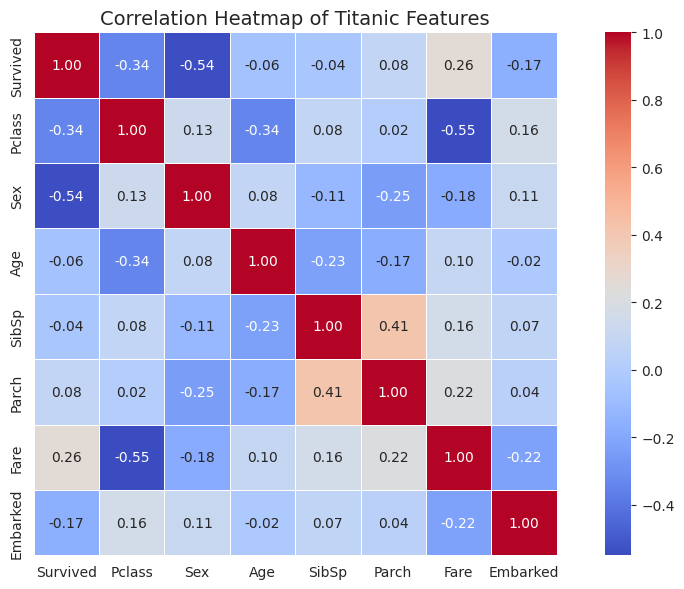

In [12]:
# visualizing correlation between all features
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            square=True)

plt.title('Correlation Heatmap of Titanic Features', fontsize=14)
plt.tight_layout()
plt.show()

## Step 3 — Training 3 Machine Learning Models

I will train 3 different classification algorithms and compare
their performance:
1. Logistic Regression — a simple linear model for classification
2. Random Forest — an ensemble of decision trees
3. K Nearest Neighbors (KNN) — predicts based on similar passengers

In [13]:
# Model 1 - Logistic Regression
# simple and interpretable linear classification model

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# predictions on test set
lr_pred = lr_model.predict(X_test)

# evaluation metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Model 1 — Logistic Regression Results:")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")

Model 1 — Logistic Regression Results:
Accuracy:  0.8101
Precision: 0.7857
Recall:    0.7432
F1 Score:  0.7639


**Model 1 — Logistic Regression:**
Accuracy of 81.01% is a solid baseline result. Precision of 78.57%
means when the model predicts survival it is correct most of the time.
Recall of 74.32% means it correctly identifies about 74% of actual
survivors. This is a good starting point for comparison.

In [14]:
# Model 2 - Random Forest Classifier
# ensemble model that combines multiple decision trees
# usually performs better than single models

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# predictions on test set
rf_pred = rf_model.predict(X_test)

# evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Model 2 — Random Forest Results:")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")

Model 2 — Random Forest Results:
Accuracy:  0.8212
Precision: 0.8088
Recall:    0.7432
F1 Score:  0.7746


**Model 2 — Random Forest:**
Random Forest improved on Logistic Regression with an accuracy of
82.12%. Precision jumped to 80.88% meaning it is more careful about
predicting survival. F1 score of 77.46% is also better than Logistic
Regression. This makes sense as Random Forest combines 100 decision
trees which reduces overfitting and captures more complex patterns.

In [15]:
# Model 3 - K Nearest Neighbors (KNN)
# predicts survival based on k most similar passengers
# using k=5 meaning it looks at 5 nearest neighbors

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# predictions on test set
knn_pred = knn_model.predict(X_test)

# evaluation metrics
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("Model 3 — KNN Results:")
print(f"Accuracy:  {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall:    {knn_recall:.4f}")
print(f"F1 Score:  {knn_f1:.4f}")

Model 3 — KNN Results:
Accuracy:  0.7039
Precision: 0.6842
Recall:    0.5270
F1 Score:  0.5954


**Model 3 — KNN:**
KNN performed the weakest of the three models with accuracy of 70.39%
and F1 score of 59.54%. The recall of 52.70% means it missed almost
half of actual survivors. KNN struggles here because it is sensitive
to the scale of features and the dataset has features with very
different ranges like Age and Fare.

## Step 4 — Model Evaluation and Comparison

Now I'll compare all 3 models side by side using a clear
comparison table to identify the best performing model.

In [16]:
# creating a comparison table for all 3 models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    'Accuracy': [lr_accuracy, rf_accuracy, knn_accuracy],
    'Precision': [lr_precision, rf_precision, knn_precision],
    'Recall': [lr_recall, rf_recall, knn_recall],
    'F1 Score': [lr_f1, rf_f1, knn_f1]
})

# rounding to 4 decimal places
results[['Accuracy', 'Precision', 'Recall', 'F1 Score']] = results[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']].round(4)

print("Model Comparison Table:")
print(results.to_string(index=False))

Model Comparison Table:
              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.8101     0.7857  0.7432    0.7639
      Random Forest    0.8212     0.8088  0.7432    0.7746
                KNN    0.7039     0.6842  0.5270    0.5954


**Model Comparison Summary:**

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Logistic Regression | 0.8101 | 0.7857 | 0.7432 | 0.7639 |
| Random Forest | 0.8212 | 0.8088 | 0.7432 | 0.7746 |
| KNN | 0.7039 | 0.6842 | 0.5270 | 0.5954 |

Random Forest is the best performing model across all metrics.
KNN is the weakest model in this comparison.

## Step 5 — Best Model Analysis and Conclusion

Random Forest performed best across all metrics. I will now
generate a confusion matrix and write the final conclusion.

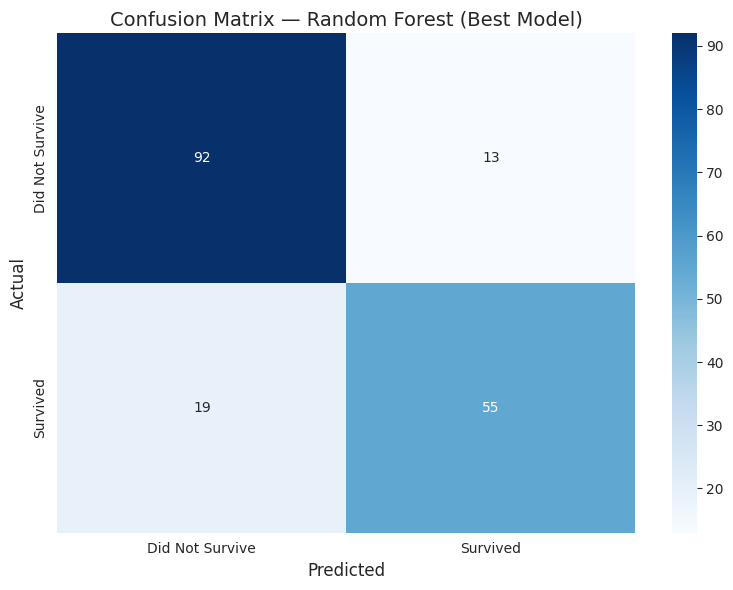


Confusion Matrix Values:
True Negatives (Correctly predicted did not survive): 92
False Positives (Wrongly predicted survived): 13
False Negatives (Wrongly predicted did not survive): 19
True Positives (Correctly predicted survived): 55


In [17]:
# confusion matrix for best model - Random Forest
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])

plt.title('Confusion Matrix — Random Forest (Best Model)', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

# printing exact numbers
print("\nConfusion Matrix Values:")
print(f"True Negatives (Correctly predicted did not survive): {cm[0][0]}")
print(f"False Positives (Wrongly predicted survived): {cm[0][1]}")
print(f"False Negatives (Wrongly predicted did not survive): {cm[1][0]}")
print(f"True Positives (Correctly predicted survived): {cm[1][1]}")

**Confusion Matrix Analysis — Random Forest:**
The model correctly predicted 92 out of 105 passengers who did not
survive and 55 out of 74 passengers who survived. It made 13 false
positive errors and 19 false negative errors. Overall 147 out of 179
test passengers were correctly classified giving us the 82.12% accuracy.

## Final Conclusion

1. Random Forest was the best performing model with 82.12% accuracy,
   80.88% precision and 77.46% F1 score — outperforming both Logistic
   Regression and KNN across all metrics.

2. Random Forest performed better because it combines 100 decision trees
   which reduces overfitting and captures complex non-linear relationships
   between features like Sex, Pclass and Fare that a single model cannot.

3. Logistic Regression was a close second with 81.01% accuracy — a strong
   result for a simple linear model showing that survival on the Titanic
   had somewhat linear patterns especially driven by gender and class.

4. KNN performed the worst with only 70.39% accuracy because it is
   sensitive to feature scaling — features like Fare (0-512) and Age
   (0-80) have very different ranges which confuses the distance
   calculation in KNN.

5. The most important features for survival prediction were Sex, Pclass
   and Fare — confirming the historical fact that women and higher class
   passengers had significantly better survival chances on the Titanic.